# Important Package

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set global font sizes

In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,              # Base font size
    'axes.titlesize': 14,         # Title size of each subplot
    'axes.labelsize': 12,         # x and y axis label size
    'xtick.labelsize': 12,        # X tick label size
    'ytick.labelsize': 12,        # Y tick label size
    'legend.fontsize': 12,        # Legend text size
    'figure.titlesize': 12,       # Main figure title
    'legend.fontsize': 12         # Legend text size
})


# UK Real Earth Metal Transportation Supply Chain with high inventory levels

In [3]:
#######################################################################################################################
# The stochastic push system function
# The starting point for the Stochastic Push System

def transport_sc(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, initial_inventories):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = initial_inventories 
        queue_delay = []
        queue_count = 0
        t = 0

#######################################################################################################################
# Computing the Instantaneous consumption 
# Instantaneous consumption algorithm starts here
        
        while t < T:
            X[:, count + 1] = X[:, count]
            Delta_C_j = np.random.poisson(lambda_j * tau)

            # Cap consumption based on available inventory
            for j in range(J):
                for k in range(nd):
                    if C_j_c[k, j] < 0:
                        max_possible = int(X[k, count + 1] / abs(C_j_c[k, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            X[:, count + 1] += C_j_c @ Delta_C_j

            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]
                t_span = tau + pT[j, 1] - pT[j, 0]
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])
                queue_count += 1

# Instantaneous consumption algorithm ends here
#######################################################################################################################

#######################################################################################################################
# Compute the delayed production
# The delayed production algorithm Starts here

            if len(queue_delay) > 0:
                for d in range(len(queue_delay)):
                    d_nq, t_nq_s, Q_nq_d, t_span = queue_delay[d]
                    if t_span > 0 and (t_nq_s >= t and t_nq_s < t + tau):
                        prob = min(((t + tau - t_nq_s) / t_span), 1)
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))
                        queue_delay[d] = [d_nq, t_nq_s, Q_nq_d, t_span]

                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

            if (t + tau) >= T:
                tau = T - t
            t += tau
            count += 1
# The delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    # Average over all runs
    X_avg = np.mean(X_all, axis=0)                # axis = 0 helps to average the state vectors  down the columns (vertically)  
    return X_avg, time

#######################################################################################################################
#######################################################################################################################


# Simulation of result
# Inputs
nd = 10                                    # total number of dimensions (number of parts)
J = 12                                      # total number of processes    9 process + 3 new birth processes
N = 500                                    # number of Monte Carlo paths
T = 500                                    # Total simulation time
                                   

# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[0, 0],           # Process 1: T_{\emptyset --> CH}  
               [0, 0],           # Process 2: T_{\emptyset --> IN} 
               [0, 0],           # Process 3: T_{\emptyset --> US} 
               [5, 7],           # Process 4: T_{CH --> M}
               [7, 9],           # Process 5: T_{IN --> S}
               [7, 9],           # Process 6: T_{US --> D}
               [0, 1],           # Process 7: T_{M}
               [9, 11],          # Process 8: T_{M --> S}
               [0, 1],           # Process 9: T_{S}
               [5, 7],           # Process 10: T_{S --> D}
               [0, 1],           # Process 11: T_{D}
               [0, 1]])          # Process 12: T_{D --> UK}


# Consumption vector
C_j_c = np.array([[0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0], 
                  [0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0], 
                  [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0], 
                  [0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0], 
                  [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0], 
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0], 
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1], 
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


# Production vector
C_j_p = np.array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
                  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
                  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
                  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], 
                  [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0], 
                  [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], 
                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], 
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

# Plot colors
colors = ['Black', 'Green', 'Purple', 'Red', 'Cyan', 'Magenta', 'Orange', 'Brown', 'DarkBlue', 'Blue']
labels = [r'$P_{\rm{CH}^+}$', r'$P_{\rm{IN}^+}$', r'$P_{\rm{US}^+}$', r'$P_{\rm{M}^-}$', r'$P_{\rm{M}^+}$', r'$P_{\rm{S}^-}$', 
                r'$P_{\rm{S}^+}$', r'$P_{\rm{D}^-}$', r'$P_{\rm{D}^+}$', r'$P_{\rm{UK}}$']

# UK Real Earth Metal Transportation Supply Chain 

# $\overline{{\lambda}}_p(t,\overline{{X}}_p(t)) = 100 \rm{~for~} p \in \{\rm{CH^+, IN^+, US^+}\}$

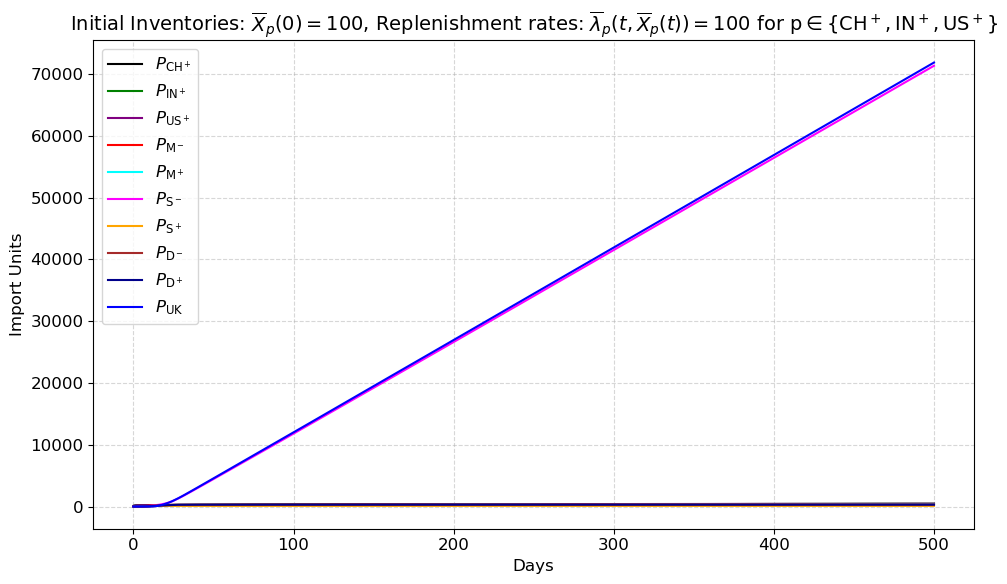

In [6]:
# initial inventories
initial_inventories  = np.array([100, 100, 100, 0, 0, 0, 0, 0, 0, 0])

#=========================== lambda_j values ===========================#
lambda_j = np.array([100,                              # Lambda_CH(0,X_CH(0))
                     100,                              # Lambda_IN(0,X_CH(0))
                     100,                              # Lambda_US(0,X_CH(0))
                     100,                              # Lambda_{T_{CH --> M}}
                     100,                              # Lambda_{T_{IN --> S}}
                     100,                              # Lambda_{T_{US --> D}}
                     100,                              # Lambda_{T_{M}}
                     100,                              # Lambda_{T_{M --> S}}
                     50,                               # Lambda_{T_{S}} 
                     200,                              # Lambda_{T_{S --> D}} 
                     200,                              # Lambda_{T_{D}} 
                     300])                             # Lambda_{T_{D --> UK}}



# Run for both taus and plot averages
taus = [2]
for tau in taus:
    X_avg, time = transport_sc(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, initial_inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])


    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = 100$, Replenishment rates: $\overline{{\lambda}}_p(t,\overline{{X}}_p(t)) = 100 \ \rm{{for}} \ p \in \{{\rm{{CH}}^+, \rm{{IN}}^+, \rm{{US}}^+\}}$')
    plt.ylabel('Import Units')
    plt.xlabel('Days')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save the figure
    plt.savefig("Birth_process_transport_SC1.png", format='png', bbox_inches='tight')  # Save before show
    plt.show()

# UK Real Earth Metal Transportation Supply Chain 
# $\bar{{\lambda}}_p(t,\overline{{X}}_p(t;\mu)) = 25 \rm{~for~} p \in \{\rm{CH^+, IN^+}\},\ \bar{{\lambda}}_p(t,\overline{{X}}_{\rm{US^+}}(t;\mu)) = 100$

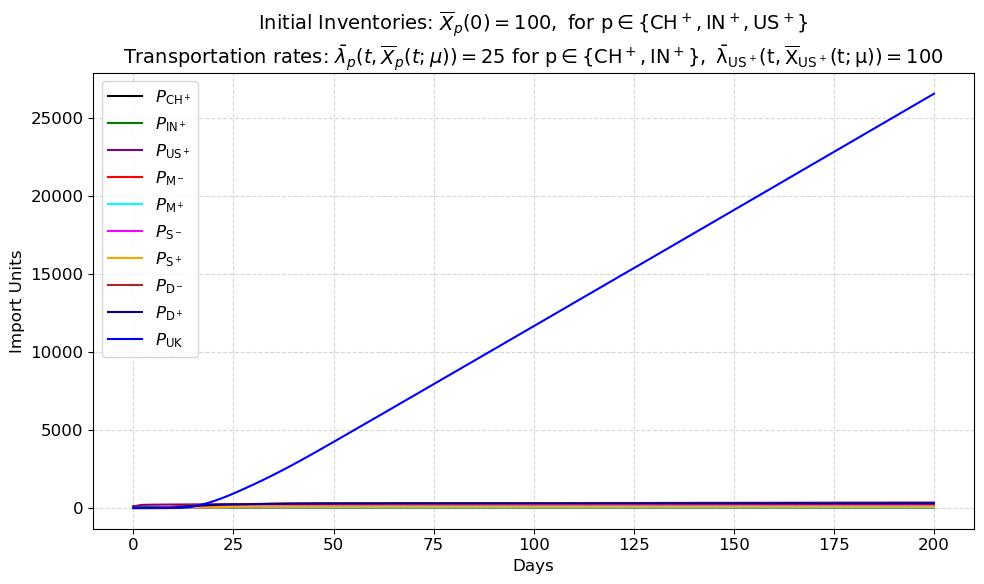

In [6]:
#=========================== initial inventories =============================#
initial_inventories  = np.array([100, 100, 100, 0, 0, 0, 0, 0, 0, 0])
T = 200

# lambda_j values
# lambda_j = np.array([25, 25, 100, 100, 100, 100, 100, 100, 50, 200, 200, 300])

#=========================== lambda_j values ===========================#
lambda_j = np.array([25,                                # Lambda_CH(0,X_CH(0))
                     25,                                # Lambda_IN(0,X_CH(0))
                     100,                               # Lambda_US(0,X_CH(0))
                     100,                               # Lambda_{T_{CH --> M}}
                     100,                               # Lambda_{T_{IN --> S}}
                     100,                               # Lambda_{T_{US --> D}}
                     100,                               # Lambda_{T_{M}}
                     100,                               # Lambda_{T_{M --> S}}
                     50,                                # Lambda_{T_{S}} 
                     200,                               # Lambda_{T_{S --> D}} 
                     200,                               # Lambda_{T_{D}} 
                     300])                              # Lambda_{T_{D --> UK}}


#=========================== Plot colors ===========================#
colors = ['Black', 'Green', 'Purple', 'Red', 'Cyan', 'Magenta', 'Orange', 'Brown', 'DarkBlue', 'Blue']

#=========================== Run for both taus and plot averages ===========================#
taus = [2]
for tau in taus:
    X_avg, time = transport_sc(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, initial_inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = {initial_inventories[0]},\ \rm{{for}} \ p \in \{{\rm{{CH}}^+, \rm{{IN}}^+, \rm{{US}}^+\}}$' + '\n' + 
              fr'Transportation rates: $\bar{{\lambda}}_p(t,\overline{{X}}_p(t;\mu)) = {lambda_j[0]} \ \rm{{for}} \ p \in \{{\rm{{CH}}^+, \rm{{IN}}^+\}},\ \bar{{\lambda}}_{{\rm{{US}}^+}}(t,\overline{{X}}_{{\rm{{US}}^+}}(t;\mu)) = {lambda_j[2]}$')
    plt.ylabel('Import Units')
    plt.xlabel('Days')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save the figure
    plt.savefig("Birth_process_transport_SC2.png", format='png', bbox_inches='tight')  # Save before show
    plt.show()